#### Multi label classification
- here we have multiple categories for same thing eg comments,


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df=pd.read_csv('toxic-comments.csv')

In [3]:
df.shape

(159571, 8)

In [4]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [5]:
comments_count=df.sum(numeric_only=True)

In [6]:
comments_count

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [7]:
comments_count.sum()

np.int64(35098)

<BarContainer object of 6 artists>

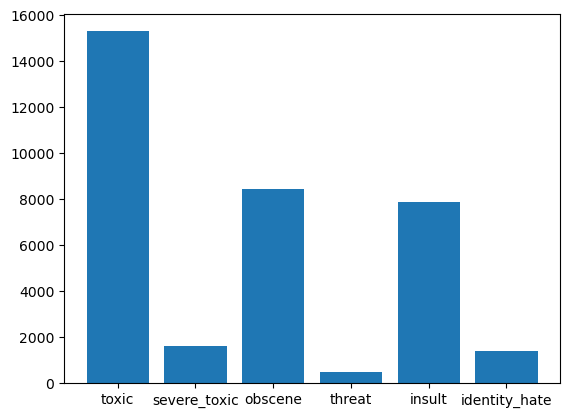

In [8]:
plt.bar(comments_count.index,comments_count)

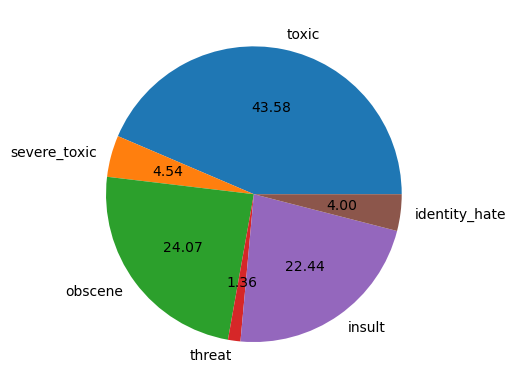

In [9]:
plt.pie(comments_count,autopct='%1.2f',labels=comments_count.index);
#  ; to avoid text which is shown before pie

In [10]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [11]:
df.value_counts

<bound method DataFrame.value_counts of                       id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2       000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4       0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
...                  ...                                                ...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159569  fff125370e4aaaf3  And it looks like it was actually you who put ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        tox

In [12]:
# to know how many comments are labled and not in any category or netural
comments_count_0 =df.sum(numeric_only=True, axis=1)
sum(comments_count_0 == 0)

143346

In [13]:
new_df=pd.DataFrame({
    'netural' : [sum(comments_count_0 == 0)],
    'toxic' : [sum(comments_count_0 != 0)]

})

In [14]:
new_df

,netural,toxic
0,143346,16225


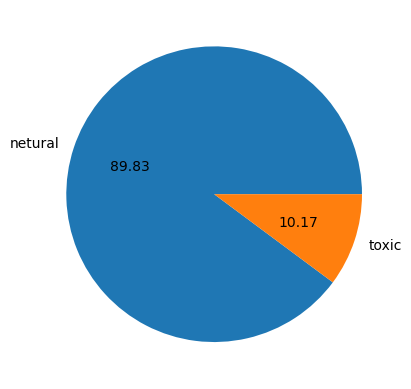

In [15]:
plt.pie(new_df.T.values.flatten(),autopct='%1.2f',labels=new_df.columns);

#### Data cleaning

In [16]:
def clean_text(text):
    text = text.lower()
    text=re.sub(r'[^a-z0-9]',' ',text)
    return text

In [17]:
sample_text='Hello, how are you?'

In [18]:
clean_text(sample_text)

'hello  how are you '

#### Define input variables


In [19]:
comments=df['comment_text']

define output vars

In [20]:
labels=df.drop(['id','comment_text'],axis=1)

In [21]:
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [22]:
# clea data
comment_text = comments.apply(clean_text)

In [23]:
comment_text

0         explanation why the edits made under my userna...
1         d aww  he matches this background colour i m s...
2         hey man  i m really not trying to edit war  it...
3           more i can t make any real suggestions on im...
4         you  sir  are my hero  any chance you remember...
                                ...                        
159566          and for the second time of asking  when ...
159567    you should be ashamed of yourself   that is a ...
159568    spitzer   umm  theres no actual article for pr...
159569    and it looks like it was actually you who put ...
159570      and     i really don t think you understand ...
Name: comment_text, Length: 159571, dtype: object

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU
from sklearn.model_selection import train_test_split

In [25]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comment_text)
sequences= tokenizer.texts_to_sequences(comment_text)
padded = pad_sequences(sequences,maxlen=200,padding='post')

In [26]:
padded

array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [  48,  732,   25, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]], dtype=int32)

In [27]:
# cross validation
X_train,X_test,y_train,y_test=train_test_split(padded,labels,random_state=0,test_size=0.2)

In [28]:
X_train.shape,y_train.shape

((127656, 200), (127656, 6))

In [29]:
X_test.shape,y_test.shape


((31915, 200), (31915, 6))

In [30]:
# model building
model=Sequential()

model.add(Embedding(5000,100,input_length=200))
model.add(GRU(128))

model.add(Dense(6,activation='sigmoid'))
# here soft max as we are having p1 probablity not muliple 

c:\Users\PGCP-AI\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
# train model
model.fit(X_train,y_train,epochs=3, validation_data=(X_test,y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 611s 152ms/step - accuracy: 0.9786 - loss: 0.0647 - val_accuracy: 0.9858 - val_loss: 0.0513
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 629s 158ms/step - accuracy: 0.9840 - loss: 0.0467 - val_accuracy: 0.9922 - val_loss: 0.0484
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 644s 161ms/step - accuracy: 0.9780 - loss: 0.0418 - val_accuracy: 0.9624 - val_loss: 0.0484


In [33]:
sample1='You are stupid. No one cares about your opinion. Just shut up.'
sample2='You are waste of time. World is better without you'

In [41]:
toxicities=['toxic','severe_toxic','obsence','threat','insult','identity_hate']

In [42]:
def predict(new_comment):
    cleaned=clean_text(new_comment)
    new_seq= tokenizer.texts_to_sequences([cleaned])
    new_padded = pad_sequences(new_seq,maxlen=200)
    prediction = model.predict(new_padded, verbose=False)
    for i in range(len(prediction[0])):
        if(prediction[0][i]>0.5):
            print(toxicities[1])
    return prediction

In [ ]:
predict(sample1)

severe_toxic


array([[0.7302474 , 0.03008513, 0.25689402, 0.00533911, 0.26675153,
        0.01736767]], dtype=float32)

In [44]:
predict(sample2)

array([[0.15050568, 0.00844422, 0.06852564, 0.0044264 , 0.03360232,
        0.00707388]], dtype=float32)